<a href="https://colab.research.google.com/github/soilapertet/CPSC-573-Project/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [239]:
# Import github repository with dataset in it
git_repo_url = 'https://github.com/soilapertet/CPSC-573-Data-Cleaning.git'

# Clone the repository
!git clone {git_repo_url}

fatal: destination path 'CPSC-573-Data-Cleaning' already exists and is not an empty directory.


In [240]:
import pandas as pd

repo_name = 'CPSC-573-Data-Cleaning'                  # repo name
file_name = 'mental-heath-in-tech-2016_20161114.csv'  # file name

file_path_github = f'/content/{repo_name}/{file_name}'

# Load the dataset into Colab
try:
    df_github = pd.read_csv(file_path_github)
    print('DataFrame loaded successfully from GitHub repository:')
    display(df_github.head())
except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found in '{repo_name}'. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

DataFrame loaded successfully from GitHub repository:


,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",...,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,What country do you live in?,What US state or territory do you live in?,What country do you work in?,What US state or territory do you work in?,Which of the following best describes your work position?,Do you work remotely?
0,0,26-100,1.0,NaN,Not eligible for coverage / N/A,NaN,No,No,I don't know,Very easy,...,Not applicable to me,Not applicable to me,39,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Sometimes
1,0,6-25,1.0,NaN,No,Yes,Yes,Yes,Yes,Somewhat easy,...,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never
2,0,6-25,1.0,NaN,No,NaN,No,No,I don't know,Neither easy nor difficult,...,Not applicable to me,Not applicable to me,38,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Always
3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Sometimes,Sometimes,43,male,United Kingdom,NaN,United Kingdom,NaN,Supervisor/Team Lead,Sometimes
4,0,6-25,0.0,1.0,Yes,Yes,No,No,No,Neither easy nor difficult,...,Sometimes,Sometimes,43,Female,United States of America,Illinois,United States of America,Illinois,Executive Leadership|Supervisor/Team Lead|Dev ...,Sometimes


# 1. Renaming Columns

In [241]:
# Create a mapping for new column names
col_mapping = {
    'Are you self-employed?': 'self_employed',
    'How many employees does your company or organization have?': 'company_size',
    'Is your employer primarily a tech company/organization?': 'tech_company',
    'Is your primary role within your company related to tech/IT?': 'tech_role',
    'Does your employer provide mental health benefits as part of healthcare coverage?': 'mh_benefits',
    'Do you know the options for mental health care available under your employer-provided coverage?': 'mh_options_awareness',
    'Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?': 'mh_formal_discussion',
    'Does your employer offer resources to learn more about mental health concerns and options for seeking help?': 'mh_resources_provided',
    'Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?': 'mh_anonymity_protected',
    'If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:': 'mh_leave_difficulty',
    'Do you think that discussing a mental health disorder with your employer would have negative consequences?': 'mh_discuss_employer_neg',
    'Do you think that discussing a physical health issue with your employer would have negative consequences?': 'ph_discuss_employer_neg',
    'Would you feel comfortable discussing a mental health disorder with your coworkers?': 'mh_discuss_coworkers',
    'Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?': 'mh_discuss_supervisor',
    'Do you feel that your employer takes mental health as seriously as physical health?': 'mh_vs_ph_seriousness',
    'Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?': 'mh_observed_neg_coworkers',
    'Do you have medical coverage (private insurance or state-provided) which includes treatment of \xa0mental health issues?': 'mh_medical_coverage',
    'Do you know local or online resources to seek help for a mental health disorder?': 'mh_resource_awareness_external',
    'If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?': 'reveal_mh_clients',
    'If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?': 'reveal_mh_clients_impact',
    'If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?': 'reveal_mh_coworkers',
    'If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?': 'reveal_mh_coworkers_impact',
    'Do you believe your productivity is ever affected by a mental health issue?': 'mh_productivity_impact',
    'If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?': 'mh_productivity_pct',
    'Do you have previous employers?': 'has_previous_employers',
    'Have your previous employers provided mental health benefits?': 'prev_mh_benefits',
    'Were you aware of the options for mental health care provided by your previous employers?': 'prev_mh_options_awareness',
    'Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?': 'prev_mh_formal_discussion',
    'Did your previous employers provide resources to learn more about mental health issues and how to seek help?': 'prev_mh_resources',
    'Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?': 'prev_mh_anonymity',
    'Do you think that discussing a mental health disorder with previous employers would have negative consequences?': 'prev_mh_discuss_neg',
    'Do you think that discussing a physical health issue with previous employers would have negative consequences?': 'prev_ph_discuss_neg',
    'Would you have been willing to discuss a mental health issue with your previous co-workers?': 'prev_mh_discuss_coworkers',
    'Would you have been willing to discuss a mental health issue with your direct supervisor(s)?': 'prev_mh_discuss_supervisor',
    'Did you feel that your previous employers took mental health as seriously as physical health?': 'prev_mh_vs_ph_seriousness',
    'Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?': 'prev_mh_observed_neg_coworkers',
    'Would you be willing to bring up a physical health issue with a potential employer in an interview?': 'interview_ph_willing',
    'Why or why not?': 'interview_ph_why',
    'Would you bring up a mental health issue with a potential employer in an interview?': 'interview_mh_willing',
    'Why or why not?.1': 'interview_mh_why',
    'Do you feel that being identified as a person with a mental health issue would hurt your career?': 'mh_hurt_career',
    'Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?': 'mh_coworker_stigma',
    'How willing would you be to share with friends and family that you have a mental illness?': 'mh_share_friends_family',
    'Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?': 'mh_unsupportive_response',
    'Have your observations of how another individual who discussed a mental health disorder made you less likely to reveal a mental health issue yourself in your current workplace?': 'mh_fear_of_disclosure',
    'Do you have a family history of mental illness?': 'family_history',
    'Have you had a mental health disorder in the past?': 'mh_history',
    'Do you currently have a mental health disorder?': 'mh_current',
    'If yes, what condition(s) have you been diagnosed with?': 'mh_diagnosed_conditions',
    'If maybe, what condition(s) do you believe you have?': 'mh_suspected_conditions',
    'Have you been diagnosed with a mental health condition by a medical professional?': 'mh_pro_diagnosis',
    'If so, what condition(s) were you diagnosed with?': 'mh_pro_conditions_list',
    'Have you ever sought treatment for a mental health issue from a mental health professional?': 'mh_treatment_sought',
    'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?': 'mh_interfere_treated',
    'If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?': 'mh_interfere_untreated',
    'What is your age?': 'age',
    'What is your gender?': 'gender',
    'What country do you live in?': 'country_of_residence',
    'What US state or territory do you live in?': 'state_of_residence',
    'What country do you work in?': 'country_work',
    'What US state or territory do you work in?': 'state_work',
    'Which of the following best describes your work position?': 'work_position',
    'Do you work remotely?': 'remote_work'
}

# Apply renaming to dataframe
df_github.rename(columns=col_mapping, inplace=True)
display(df_github)

,self_employed,company_size,tech_company,tech_role,mh_benefits,mh_options_awareness,mh_formal_discussion,mh_resources_provided,mh_anonymity_protected,mh_leave_difficulty,...,mh_interfere_treated,mh_interfere_untreated,age,gender,country_of_residence,state_of_residence,country_work,state_work,work_position,remote_work
0,0,26-100,1.0,NaN,Not eligible for coverage / N/A,NaN,No,No,I don't know,Very easy,...,Not applicable to me,Not applicable to me,39,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Sometimes
1,0,6-25,1.0,NaN,No,Yes,Yes,Yes,Yes,Somewhat easy,...,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never
2,0,6-25,1.0,NaN,No,NaN,No,No,I don't know,Neither easy nor difficult,...,Not applicable to me,Not applicable to me,38,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Always
3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Sometimes,Sometimes,43,male,United Kingdom,NaN,United Kingdom,NaN,Supervisor/Team Lead,Sometimes
4,0,6-25,0.0,1.0,Yes,Yes,No,No,No,Neither easy nor difficult,...,Sometimes,Sometimes,43,Female,United States of America,Illinois,United States of America,Illinois,Executive Leadership|Supervisor/Team Lead|Dev ...,Sometimes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1428,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Not applicable to me,Not applicable to me,34,Female,United States of America,New York,United States of America,New York,Other,Sometimes
1429,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Sometimes,Often,56,MALE,United States of America,California,Afghanistan,NaN,Support,Sometimes
1430,0,100-500,1.0,NaN,Yes,Yes,Yes,Yes,I don't know,Somewhat difficult,...,Rarely,Sometimes,52,Male,United States of America,Georgia,United States of America,Georgia,Back-end Developer,Sometimes
1431,0,100-500,0.0,1.0,I don't know,I am not sure,No,Yes,I don't know,Somewhat difficult,...,Sometimes,Often,30,Female,United States of America,Nebraska,United States of America,Nebraska,DevOps/SysAdmin,Sometimes


# 2. Convert binary values to True/False values


In [242]:
# List columns with binary values (0 or 1)
binary_cols = ['self_employed',
               'tech_company',
               'tech_role',
               'mh_medical_coverage',
               'has_previous_employers',
               'mh_treatment_sought'
               ]

# Create a mapping for True/False values
binary_mapping = {
    0 : 'False',
    1 : 'True'
}

# Apply mapping
for col in binary_cols:
  df_github[col] = df_github[col].map(binary_mapping)

display(df_github)

,self_employed,company_size,tech_company,tech_role,mh_benefits,mh_options_awareness,mh_formal_discussion,mh_resources_provided,mh_anonymity_protected,mh_leave_difficulty,...,mh_interfere_treated,mh_interfere_untreated,age,gender,country_of_residence,state_of_residence,country_work,state_work,work_position,remote_work
0,False,26-100,True,NaN,Not eligible for coverage / N/A,NaN,No,No,I don't know,Very easy,...,Not applicable to me,Not applicable to me,39,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Sometimes
1,False,6-25,True,NaN,No,Yes,Yes,Yes,Yes,Somewhat easy,...,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never
2,False,6-25,True,NaN,No,NaN,No,No,I don't know,Neither easy nor difficult,...,Not applicable to me,Not applicable to me,38,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Always
3,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Sometimes,Sometimes,43,male,United Kingdom,NaN,United Kingdom,NaN,Supervisor/Team Lead,Sometimes
4,False,6-25,False,True,Yes,Yes,No,No,No,Neither easy nor difficult,...,Sometimes,Sometimes,43,Female,United States of America,Illinois,United States of America,Illinois,Executive Leadership|Supervisor/Team Lead|Dev ...,Sometimes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1428,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Not applicable to me,Not applicable to me,34,Female,United States of America,New York,United States of America,New York,Other,Sometimes
1429,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Sometimes,Often,56,MALE,United States of America,California,Afghanistan,NaN,Support,Sometimes
1430,False,100-500,True,NaN,Yes,Yes,Yes,Yes,I don't know,Somewhat difficult,...,Rarely,Sometimes,52,Male,United States of America,Georgia,United States of America,Georgia,Back-end Developer,Sometimes
1431,False,100-500,False,True,I don't know,I am not sure,No,Yes,I don't know,Somewhat difficult,...,Sometimes,Often,30,Female,United States of America,Nebraska,United States of America,Nebraska,DevOps/SysAdmin,Sometimes


# 3. Handling missing responses/Null values


In [243]:
# Drop columns where majority of individuals did not respond
# Keep only columns that have at least 500 non-null values
df_clean = df_github.dropna(thresh=500, axis=1)

# Filter self-employed individuals
df_clean = df_clean[df_clean['self_employed'] != 'True']
df_clean = df_clean.drop(columns=['self_employed'])

# Save a list of columns will be working with for future reference
max_responses_cols = list(df_clean.columns)

df_clean.reset_index(drop=True, inplace=True)
display(df_clean)

,company_size,tech_company,mh_benefits,mh_options_awareness,mh_formal_discussion,mh_resources_provided,mh_anonymity_protected,mh_leave_difficulty,mh_discuss_employer_neg,ph_discuss_employer_neg,...,mh_interfere_treated,mh_interfere_untreated,age,gender,country_of_residence,state_of_residence,country_work,state_work,work_position,remote_work
0,26-100,True,Not eligible for coverage / N/A,NaN,No,No,I don't know,Very easy,No,No,...,Not applicable to me,Not applicable to me,39,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Sometimes
1,6-25,True,No,Yes,Yes,Yes,Yes,Somewhat easy,No,No,...,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never
2,6-25,True,No,NaN,No,No,I don't know,Neither easy nor difficult,Maybe,No,...,Not applicable to me,Not applicable to me,38,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Always
3,6-25,False,Yes,Yes,No,No,No,Neither easy nor difficult,Yes,Maybe,...,Sometimes,Sometimes,43,Female,United States of America,Illinois,United States of America,Illinois,Executive Leadership|Supervisor/Team Lead|Dev ...,Sometimes
4,More than 1000,True,Yes,I am not sure,No,Yes,Yes,Somewhat easy,Yes,Yes,...,Not applicable to me,Often,42,Male,United Kingdom,NaN,United Kingdom,NaN,DevOps/SysAdmin|Support|Back-end Developer|Fro...,Sometimes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1141,100-500,True,I don't know,I am not sure,No,I don't know,I don't know,Somewhat easy,Maybe,No,...,Rarely,Often,26,Female,Canada,NaN,Canada,NaN,Other,Sometimes
1142,500-1000,True,Yes,No,No,No,Yes,Somewhat easy,No,No,...,Rarely,Often,38,female,United States of America,Illinois,United States of America,Illinois,Support,Always
1143,100-500,True,Yes,Yes,Yes,Yes,I don't know,Somewhat difficult,Maybe,Maybe,...,Rarely,Sometimes,52,Male,United States of America,Georgia,United States of America,Georgia,Back-end Developer,Sometimes
1144,100-500,False,I don't know,I am not sure,No,Yes,I don't know,Somewhat difficult,Maybe,No,...,Sometimes,Often,30,Female,United States of America,Nebraska,United States of America,Nebraska,DevOps/SysAdmin,Sometimes


In [244]:
# Clean responses in state_of_residence and state_work columns
# (responses not in the US)
def clean_state_responses(state):
  if pd.isna(state):
    return 'International'

  return str(state).strip().title()

state_cols = ['state_of_residence', 'state_work']

for col in state_cols:
  df_clean[col] = df_clean[col].copy().apply(clean_state_responses)

display(df_clean)

,company_size,tech_company,mh_benefits,mh_options_awareness,mh_formal_discussion,mh_resources_provided,mh_anonymity_protected,mh_leave_difficulty,mh_discuss_employer_neg,ph_discuss_employer_neg,...,mh_interfere_treated,mh_interfere_untreated,age,gender,country_of_residence,state_of_residence,country_work,state_work,work_position,remote_work
0,26-100,True,Not eligible for coverage / N/A,NaN,No,No,I don't know,Very easy,No,No,...,Not applicable to me,Not applicable to me,39,Male,United Kingdom,International,United Kingdom,International,Back-end Developer,Sometimes
1,6-25,True,No,Yes,Yes,Yes,Yes,Somewhat easy,No,No,...,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never
2,6-25,True,No,NaN,No,No,I don't know,Neither easy nor difficult,Maybe,No,...,Not applicable to me,Not applicable to me,38,Male,United Kingdom,International,United Kingdom,International,Back-end Developer,Always
3,6-25,False,Yes,Yes,No,No,No,Neither easy nor difficult,Yes,Maybe,...,Sometimes,Sometimes,43,Female,United States of America,Illinois,United States of America,Illinois,Executive Leadership|Supervisor/Team Lead|Dev ...,Sometimes
4,More than 1000,True,Yes,I am not sure,No,Yes,Yes,Somewhat easy,Yes,Yes,...,Not applicable to me,Often,42,Male,United Kingdom,International,United Kingdom,International,DevOps/SysAdmin|Support|Back-end Developer|Fro...,Sometimes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1141,100-500,True,I don't know,I am not sure,No,I don't know,I don't know,Somewhat easy,Maybe,No,...,Rarely,Often,26,Female,Canada,International,Canada,International,Other,Sometimes
1142,500-1000,True,Yes,No,No,No,Yes,Somewhat easy,No,No,...,Rarely,Often,38,female,United States of America,Illinois,United States of America,Illinois,Support,Always
1143,100-500,True,Yes,Yes,Yes,Yes,I don't know,Somewhat difficult,Maybe,Maybe,...,Rarely,Sometimes,52,Male,United States of America,Georgia,United States of America,Georgia,Back-end Developer,Sometimes
1144,100-500,False,I don't know,I am not sure,No,Yes,I don't know,Somewhat difficult,Maybe,No,...,Sometimes,Often,30,Female,United States of America,Nebraska,United States of America,Nebraska,DevOps/SysAdmin,Sometimes


In [245]:
# Clean responses in the medical conditions columns
def clean_mh_responses(condition):
  if pd.isna(condition):
    return 'None/Not Disclosed'

  return str(condition).strip().title()

medical_cols = ['mh_diagnosed_conditions', 'mh_pro_conditions_list']

for col in medical_cols:
  df_clean[col] = df_clean[col].copy().apply(clean_mh_responses)

display(df_clean)

,company_size,tech_company,mh_benefits,mh_options_awareness,mh_formal_discussion,mh_resources_provided,mh_anonymity_protected,mh_leave_difficulty,mh_discuss_employer_neg,ph_discuss_employer_neg,...,mh_interfere_treated,mh_interfere_untreated,age,gender,country_of_residence,state_of_residence,country_work,state_work,work_position,remote_work
0,26-100,True,Not eligible for coverage / N/A,NaN,No,No,I don't know,Very easy,No,No,...,Not applicable to me,Not applicable to me,39,Male,United Kingdom,International,United Kingdom,International,Back-end Developer,Sometimes
1,6-25,True,No,Yes,Yes,Yes,Yes,Somewhat easy,No,No,...,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never
2,6-25,True,No,NaN,No,No,I don't know,Neither easy nor difficult,Maybe,No,...,Not applicable to me,Not applicable to me,38,Male,United Kingdom,International,United Kingdom,International,Back-end Developer,Always
3,6-25,False,Yes,Yes,No,No,No,Neither easy nor difficult,Yes,Maybe,...,Sometimes,Sometimes,43,Female,United States of America,Illinois,United States of America,Illinois,Executive Leadership|Supervisor/Team Lead|Dev ...,Sometimes
4,More than 1000,True,Yes,I am not sure,No,Yes,Yes,Somewhat easy,Yes,Yes,...,Not applicable to me,Often,42,Male,United Kingdom,International,United Kingdom,International,DevOps/SysAdmin|Support|Back-end Developer|Fro...,Sometimes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1141,100-500,True,I don't know,I am not sure,No,I don't know,I don't know,Somewhat easy,Maybe,No,...,Rarely,Often,26,Female,Canada,International,Canada,International,Other,Sometimes
1142,500-1000,True,Yes,No,No,No,Yes,Somewhat easy,No,No,...,Rarely,Often,38,female,United States of America,Illinois,United States of America,Illinois,Support,Always
1143,100-500,True,Yes,Yes,Yes,Yes,I don't know,Somewhat difficult,Maybe,Maybe,...,Rarely,Sometimes,52,Male,United States of America,Georgia,United States of America,Georgia,Back-end Developer,Sometimes
1144,100-500,False,I don't know,I am not sure,No,Yes,I don't know,Somewhat difficult,Maybe,No,...,Sometimes,Often,30,Female,United States of America,Nebraska,United States of America,Nebraska,DevOps/SysAdmin,Sometimes


# 4. Cleaning response variations and outliers

In [246]:
def clean_gender_responses(gender):
  # Check if value was provided for the gender
  if pd.isna(gender):
    return 'Other/Not Stated'

  # Normalize string; remove whitespace and make lowercase
  clean_str = str(gender).strip().lower()

  # Define gender variations
  female_variations = ['female', 'woman', 'f', 'fem', 'afab', 'cis female']
  male_variations = ['male', 'man', 'm', 'dude', 'guy', 'mail', 'cis male']

  # Categorize Female responses
  if any(variation in clean_str for variation in female_variations):
    return 'Female'

  # Categorize Male responses
  if any(variation in clean_str for variation in male_variations):
    return 'Male'

  # Categorize Non-binary responses
  return 'Non-binary/Other'


# Applying cleaning function on dataframe
df_clean['gender'] = df_clean['gender'].copy().apply(clean_gender_responses)
display(df_clean)

,company_size,tech_company,mh_benefits,mh_options_awareness,mh_formal_discussion,mh_resources_provided,mh_anonymity_protected,mh_leave_difficulty,mh_discuss_employer_neg,ph_discuss_employer_neg,...,mh_interfere_treated,mh_interfere_untreated,age,gender,country_of_residence,state_of_residence,country_work,state_work,work_position,remote_work
0,26-100,True,Not eligible for coverage / N/A,NaN,No,No,I don't know,Very easy,No,No,...,Not applicable to me,Not applicable to me,39,Male,United Kingdom,International,United Kingdom,International,Back-end Developer,Sometimes
1,6-25,True,No,Yes,Yes,Yes,Yes,Somewhat easy,No,No,...,Rarely,Sometimes,29,Male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never
2,6-25,True,No,NaN,No,No,I don't know,Neither easy nor difficult,Maybe,No,...,Not applicable to me,Not applicable to me,38,Male,United Kingdom,International,United Kingdom,International,Back-end Developer,Always
3,6-25,False,Yes,Yes,No,No,No,Neither easy nor difficult,Yes,Maybe,...,Sometimes,Sometimes,43,Female,United States of America,Illinois,United States of America,Illinois,Executive Leadership|Supervisor/Team Lead|Dev ...,Sometimes
4,More than 1000,True,Yes,I am not sure,No,Yes,Yes,Somewhat easy,Yes,Yes,...,Not applicable to me,Often,42,Male,United Kingdom,International,United Kingdom,International,DevOps/SysAdmin|Support|Back-end Developer|Fro...,Sometimes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1141,100-500,True,I don't know,I am not sure,No,I don't know,I don't know,Somewhat easy,Maybe,No,...,Rarely,Often,26,Female,Canada,International,Canada,International,Other,Sometimes
1142,500-1000,True,Yes,No,No,No,Yes,Somewhat easy,No,No,...,Rarely,Often,38,Female,United States of America,Illinois,United States of America,Illinois,Support,Always
1143,100-500,True,Yes,Yes,Yes,Yes,I don't know,Somewhat difficult,Maybe,Maybe,...,Rarely,Sometimes,52,Male,United States of America,Georgia,United States of America,Georgia,Back-end Developer,Sometimes
1144,100-500,False,I don't know,I am not sure,No,Yes,I don't know,Somewhat difficult,Maybe,No,...,Sometimes,Often,30,Female,United States of America,Nebraska,United States of America,Nebraska,DevOps/SysAdmin,Sometimes


In [247]:
# Remove outliers in age column
df_clean = df_clean[(df_clean['age'] >= 18) & (df_clean['age'] <= 65)]

# Remove the self_employed column
display(df_clean)

,company_size,tech_company,mh_benefits,mh_options_awareness,mh_formal_discussion,mh_resources_provided,mh_anonymity_protected,mh_leave_difficulty,mh_discuss_employer_neg,ph_discuss_employer_neg,...,mh_interfere_treated,mh_interfere_untreated,age,gender,country_of_residence,state_of_residence,country_work,state_work,work_position,remote_work
0,26-100,True,Not eligible for coverage / N/A,NaN,No,No,I don't know,Very easy,No,No,...,Not applicable to me,Not applicable to me,39,Male,United Kingdom,International,United Kingdom,International,Back-end Developer,Sometimes
1,6-25,True,No,Yes,Yes,Yes,Yes,Somewhat easy,No,No,...,Rarely,Sometimes,29,Male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never
2,6-25,True,No,NaN,No,No,I don't know,Neither easy nor difficult,Maybe,No,...,Not applicable to me,Not applicable to me,38,Male,United Kingdom,International,United Kingdom,International,Back-end Developer,Always
3,6-25,False,Yes,Yes,No,No,No,Neither easy nor difficult,Yes,Maybe,...,Sometimes,Sometimes,43,Female,United States of America,Illinois,United States of America,Illinois,Executive Leadership|Supervisor/Team Lead|Dev ...,Sometimes
4,More than 1000,True,Yes,I am not sure,No,Yes,Yes,Somewhat easy,Yes,Yes,...,Not applicable to me,Often,42,Male,United Kingdom,International,United Kingdom,International,DevOps/SysAdmin|Support|Back-end Developer|Fro...,Sometimes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1141,100-500,True,I don't know,I am not sure,No,I don't know,I don't know,Somewhat easy,Maybe,No,...,Rarely,Often,26,Female,Canada,International,Canada,International,Other,Sometimes
1142,500-1000,True,Yes,No,No,No,Yes,Somewhat easy,No,No,...,Rarely,Often,38,Female,United States of America,Illinois,United States of America,Illinois,Support,Always
1143,100-500,True,Yes,Yes,Yes,Yes,I don't know,Somewhat difficult,Maybe,Maybe,...,Rarely,Sometimes,52,Male,United States of America,Georgia,United States of America,Georgia,Back-end Developer,Sometimes
1144,100-500,False,I don't know,I am not sure,No,Yes,I don't know,Somewhat difficult,Maybe,No,...,Sometimes,Often,30,Female,United States of America,Nebraska,United States of America,Nebraska,DevOps/SysAdmin,Sometimes


# 5. Denormalize columns associated medical conditions and work position


In [248]:
tech_data = df_clean.copy()

# Create a separate dataframe with denormalized mh conditions
df_mh_conditions = tech_data[['company_size', 'tech_company', 'mh_pro_conditions_list','age', 'gender', 'country_of_residence', 'country_work', 'remote_work']].copy()

df_mh_conditions = df_mh_conditions.assign(
      pro_diagnosis = df_mh_conditions ['mh_pro_conditions_list'].str.split('|')
  ).explode('pro_diagnosis').reset_index().rename(columns={'index': 'respondent_id'})

# Create a separate datframe wih denormalize work position
df_work_positions = tech_data[['company_size', 'tech_company', 'mh_pro_conditions_list','age', 'gender', 'country_of_residence', 'country_work', 'work_position', 'remote_work']].copy()
df_work_positions = df_work_positions.assign(
    position = df_work_positions['work_position'].str.split('|')
).explode('position').reset_index().rename(columns={'index': 'respondent_id'})

# Visualizations


## How have perceptions of employer support for mental health changed between respondents’ previous and current workplaces?

In [249]:
# Imports
import pandas as pd

# ===== MAPPING ===== #
# Create an emotional mapping
# a) Current workplace
current_wp_mapping = {
    "Yes": 1,
    "I don't know": 0.5,
    "I am not sure": 0.5,
    "No": 0,
    "Not eligible for coverage / N/A": None
}

# b) Previous workplace
previous_wp_mapping = {
    "Yes, they all did": 2,
    "Some did": 1,
    "I don't know": 0.5,
    "No, none did": 0,
    "None did": 0,
}

# c) Previous workplace resource awarenes
previous_awareness_mapping = {
    "Yes, I was aware of all of them": 2,
    "I was aware of some": 1,
    "No, I only became aware later": 0,
    "N/A (not currently aware)": None
}

# ===== FIELD & FUNCTION DEFINITION ===== #
# Define fields related to employee support for mental health
mh_support_current = [
    'mh_benefits',
    'mh_options_awareness',
    'mh_formal_discussion',
    'mh_resources_provided'
]

mh_support_previous = [
    'prev_mh_benefits',
    'prev_mh_formal_discussion',
    'prev_mh_resources'
]

# Define a function to classify support change
def classify_support_change(change):
  if change > 0:
    return 'Improved'
  elif change < 0:
    return 'Worsened'
  else:
    return 'No Change'

# ===== APPLY MAPPING ===== #
for field in mh_support_current:
    tech_data[field] = tech_data[field].map(current_wp_mapping)

for field in mh_support_previous:
    tech_data[field] = tech_data[field].map(previous_wp_mapping)

tech_data['prev_mh_options_awareness'] = tech_data['prev_mh_options_awareness'].map(previous_awareness_mapping)

# ===== CALCULATIONS ===== #
# Calculate the mean score across the support columns
tech_data['current_support_score'] = tech_data[mh_support_current].mean(axis=1, skipna=True)
tech_data['previous_support_score'] = tech_data[mh_support_previous + ['prev_mh_options_awareness']].mean(axis=1, skipna=True)

 # Normalize to 0 -> 1 scale
tech_data['previous_support_score'] = tech_data['previous_support_score'] / 2

# Drop rows with null values in support score columns
tech_data = tech_data.dropna(subset=['current_support_score', 'previous_support_score'])

tech_data['support_change'] = tech_data['current_support_score'] - tech_data['previous_support_score']
tech_data['support_change_category'] = tech_data['support_change'].apply(classify_support_change)

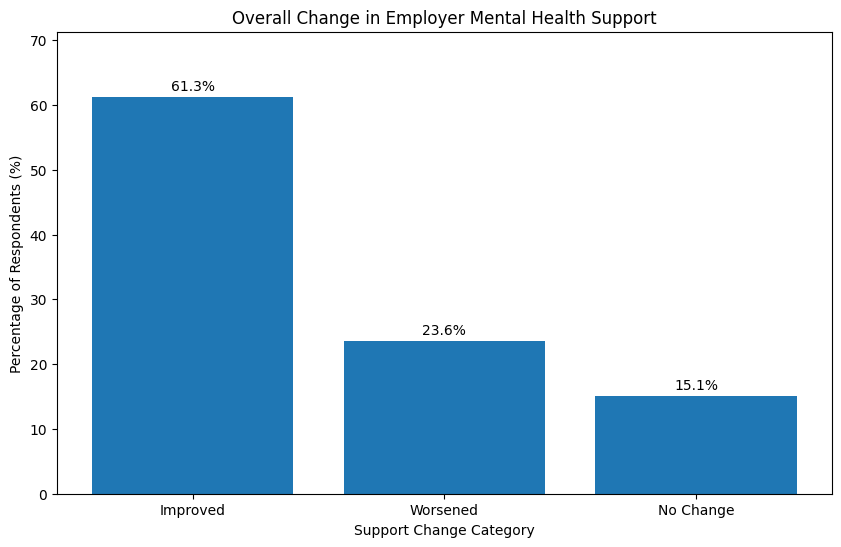

In [250]:
import matplotlib.pyplot as plt

change_summary = tech_data['support_change_category'].value_counts(normalize=True) * 100

plt.figure(figsize=(10, 6))
plt.bar(change_summary.index, change_summary.values)

# Add labels
for i, v in enumerate(change_summary.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.title('Overall Change in Employer Mental Health Support')
plt.ylabel('Percentage of Respondents (%)')
plt.xlabel('Support Change Category')
plt.xticks(rotation=0)
plt.ylim(0, max(change_summary.values) + 10)

plt.show()

In [251]:
import plotly.graph_objects as go

# Define a function to classify support score
def classify_support_score(score):
  if score >= 0.7:
    return 'High'
  elif score >= 0.5:
    return 'Medium'
  else:
    return 'Low'

tech_data['previous_support_level'] = tech_data['previous_support_score'].apply(classify_support_score)
tech_data['current_support_level'] = tech_data['current_support_score'].apply(classify_support_score)

# Build a transition table - group changes e.g Low -> Medium, Low -> Low, High -> Low
transition = tech_data.groupby(['previous_support_level', 'current_support_level']).size().reset_index(name='count')

# Define the nodes for Spanky diagram
labels = [
    "Previous: Low", "Previous: Medium", "Previous: High",
    "Current: Low", "Current: Medium", "Current: High"
]

# Create a lookup dictionary
label_dict = {label: i for i, label in enumerate(labels)}

source = []
target = []
values = []

# Build the connections (flows)
for _, row in transition.iterrows():
    source.append(label_dict[f"Previous: {row['previous_support_level']}"])
    target.append(label_dict[f"Current: {row['current_support_level']}"])
    values.append(row['count'])

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=30,
        thickness=20,
        label=labels
    ),
    link=dict(
        source=source,
        target=target,
        value=values,
        label=[f"{v} respondents" for v in values]
    )
)])

fig.update_layout(
    title_text="Change in Employer Mental Health Support (Previous → Current)",
    title_x=0.5,
    font_size=12,
    height=500,
    width=900,
    margin=dict(l=50, r=50, t=50, b=50)
)

fig.show()

## Are there differences in mental health diagnosis rates across countries, and how do these differences relate to levels of workplace awareness and support?

In [252]:
# Define mental health coniditions
mh_conditions = {
    'anxiety' : 'anxiety disorder',
    'depression/bipolar' : 'mood disorder',
    'adhd' : 'attention deficit hyperactivity disorder',
}

mh_support_cols = [
    'mh_benefits',
    'mh_options_awareness',
    'mh_formal_discussion',
    'mh_resources_provided'
]

# ===== MENTAL HEALTH DIAGNOSIS RATE CALCULATION ===== #

# Count respondents per country
country_counts = tech_data['country_work'].value_counts().reset_index()
country_counts.columns = ['country_work', 'respondent_count']

# Filter countries
min_count = 10
valid_countries = country_counts[country_counts['respondent_count'] >= min_count]['country_work']

tech_data_filtered = tech_data[tech_data['country_work'].isin(valid_countries)].copy()

# Mental health conditions
mh_conditions = {
    'anxiety': 'anxiety disorder',
    'depression/bipolar': 'mood disorder',
    'adhd': 'attention deficit hyperactivity disorder',
}

# Create binary columns
for key, val in mh_conditions.items():
    tech_data_filtered[key] = tech_data_filtered['mh_pro_conditions_list'].str.lower().str.contains(val, na=False).astype(int)

# Group by country
country_mh_conditions = tech_data_filtered.groupby('country_work')[list(mh_conditions.keys())].mean().reset_index()

# Overall diagnosis rate
country_mh_conditions['overall_diagnosis_rate'] = country_mh_conditions[
    ['anxiety', 'depression/bipolar', 'adhd']
].mean(axis=1)

# Workplace support
country_support = tech_data_filtered.groupby('country_work')[mh_support_cols].mean().reset_index()

# Merge
country_analysis = pd.merge(country_mh_conditions, country_support, on='country_work')

# Add respondent counts
country_analysis = pd.merge(country_analysis, country_counts, on='country_work')

# Support score
country_analysis['support_score'] = country_analysis[mh_support_cols].mean(axis=1)

# Rename columns to make them more intuitive before mapping out the data
country_mh_conditions = country_mh_conditions.rename(columns={
    'country_work': 'Country',
    'anxiety': 'Anxiety',
    'depression/bipolar': 'Depression/Bipolar',
    'adhd': 'ADHD',
    'overall_diagnosis_rate': 'Overall Mental Diagnosis Rate'
})

country_analysis = country_analysis.rename(columns={
    'country_work' : 'Country',
    'support_score' : 'Workplace Mental Health Support Index',
    'overall_diagnosis_rate': 'Overall Mental Diagnosis Rate'
})


In [253]:
import plotly.express as px

fig = px.choropleth(
    country_mh_conditions,
    locations='Country',
    locationmode='country names',
    color='Overall Mental Diagnosis Rate',
    color_continuous_scale='YlOrRd',
    custom_data=[
        'Anxiety',
        'Depression/Bipolar',
        'ADHD'
    ],
    title='Mental Health Diagnosis Rates by Country'
)

fig.update_traces(
    hovertemplate=
    "<b>%{location}</b><br><br>" +
    "Anxiety: %{customdata[0]:.1%}<br>" +
    "Depression/Bipolar: %{customdata[1]:.1%}<br>" +
    "ADHD: %{customdata[2]:.1%}<br><br>" +
    "<b>Overall Rate: %{z:.1%}</b><extra></extra>"
)

fig.update_layout(
    title_x=0.5,
    coloraxis_colorbar=dict(
        title="Diagnosis Rate",
        tickformat=".0%"
    )
)

fig.update_geos(
    showcoastlines=True,
    coastlinecolor="gray",
    showland=True,
    landcolor="lightgray"
)

fig.show()

In [254]:
fig = px.scatter(
    country_analysis,
    x='Workplace Mental Health Support Index',
    y='Overall Mental Diagnosis Rate',
    size='Workplace Mental Health Support Index',
    hover_name='Country',
    hover_data={
        'Workplace Mental Health Support Index': ':.0%',
        'Overall Mental Diagnosis Rate': ':.0%'
    },
    title='Workplace Support vs Mental Health Diagnosis Rates',
    text='Country'
)

fig.update_traces(textposition='top center')
fig.update_layout(
    title_x=0.5,
    xaxis_title="Workplace Mental Health Support Index",
    yaxis_title="Mental Health Diagnosis Rate",
    xaxis_tickformat=".0%",
    yaxis_tickformat=".0%"
)

fig.show()